# Импорты

In [12]:
import os
import sys
import random
import subprocess
import re
import warnings
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# Фиксируем seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Установка необходимых пакетов (если их нет)
def ensure_package(pkg, import_name=None):
    target = import_name or pkg
    try:
        __import__(target)
    except ImportError:
        print(f"Устанавливаем {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure_package("faiss-cpu", "faiss")
ensure_package("sentence-transformers")

import faiss
from sentence_transformers import SentenceTransformer

# Устройство
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except:
    DEVICE = "cpu"
print(f"Устройство: {DEVICE}")

if DEVICE == "cuda":
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("NumPy:", np.__version__)
print("FAISS доступен")
print("sentence-transformers доступен")

print(f"Python:       {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}")

os.makedirs("artifacts", exist_ok=True)

Устанавливаем sentence-transformers...
Устройство: cpu
NumPy: 2.3.5
FAISS доступен
sentence-transformers доступен
Python:       3.14.0


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cpu


# База знаний

In [3]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Зигмунд Фрейд и основы психоанализа",
        "text": (
            "Зигмунд Фрейд основал психоанализ в конце XIX века как метод лечения и теорию личности. "
            "Этот подход изучает бессознательные процессы, влияющие на поведение человека. "
            "Основные идеи включают роль детских травм, сновидений и бессознательных конфликтов."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Бессознательное",
        "text": (
            "Бессознательное – центральное понятие психоанализа. "
            "Оно содержит вытесненные желания, воспоминания и импульсы, недоступные сознанию. "
            "Однако бессознательное активно влияет на мысли, чувства и поступки человека."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Структура личности: Оно, Я, Сверх-Я",
        "text": (
            "Фрейд выделил три инстанции психики: Оно (инстинкты), Я (реальность) и Сверх-Я (мораль). "
            "Оно требует немедленного удовлетворения желаний, а Сверх-Я накладывает ограничения. "
            "Я балансирует между ними, адаптируя человека к внешней среде."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Защитные механизмы психики",
        "text": (
            "Защитные механизмы используются Я для снижения тревоги и сохранения целостности. "
            "К ним относятся вытеснение, проекция, рационализация и сублимация. "
            "Чрезмерное использование защит может приводить к неврозам и искажению реальности."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Толкование сновидений",
        "text": (
            "Фрейд называл сновидения «королевской дорогой к бессознательному». "
            "Сновидения рассматриваются как замаскированное исполнение вытесненных желаний. "
            "Анализ символов снов помогает понять скрытые конфликты пациента."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Психосексуальное развитие",
        "text": (
            "Психоанализ предполагает, что личность формируется через стадии психосексуального развития. "
            "Стадии включают оральную, анальную, фаллическую, латентную и генитальную. "
            "Фиксация на одной из стадий может определить черты характера во взрослом возрасте."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Эдипов комплекс",
        "text": (
            "Эдипов комплекс возникает в фаллической стадии развития у детей. "
            "Он характеризуется бессознательным влечением к родителю противоположного пола и ревностью к родителю своего пола. "
            "Успешное разрешение этого конфликта важно для формирования идентичности."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Либидо и инстинкты",
        "text": (
            "Либидо в психоанализе – это психическая энергия сексуальных влечений. "
            "Фрейд также выделял инстинкт смерти (Танатос) как противоположность инстинкту жизни (Эрос). "
            "Баланс этих сил определяет динамику психической жизни."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Метод свободных ассоциаций",
        "text": (
            "Свободные ассоциации – основной технический прием психоанализа. "
            "Пациент говорит все, что приходит в голову, без цензуры и логической связности. "
            "Это позволяет обойти защиты и выявить бессознательный материал."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Перенос в терапии",
        "text": (
            "Перенос – это процесс, когда пациент бессознательно проецирует на аналитика чувства к значимым фигурам прошлого. "
            "Анализ переноса является ключевым инструментом терапии. "
            "Через него прорабатываются старые конфликты в безопасной обстановке."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Контрперенос",
        "text": (
            "Контрперенос – это эмоциональная реакция аналитика на пациента. "
            "Раньше это считалось помехой, сейчас признается важным источником информации. "
            "Аналитик должен осознавать свои чувства, чтобы использовать их в работе, а не действовать под их влиянием."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Сопротивление",
        "text": (
            "Сопротивление – это силы, которые препятствуют продвижению терапии и осознанию бессознательного. "
            "Оно может проявляться в опозданиях, молчании или отрицании интерпретаций. "
            "Преодоление сопротивления – необходимая часть аналитической работы."
        ),
    },
    {
        "doc_id": "doc_13",
        "title": "Карл Юнг и архетипы",
        "text": (
            "Карл Юнг развивал аналитическую психологию, введя понятие коллективного бессознательного. "
            "Архетипы – это универсальные врожденные психические структуры, такие как Тень, Анима, Анимус. "
            "Индивидуация – процесс становления целостной личности через интеграцию этих частей."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Альфред Адлер и комплекс неполноценности",
        "text": (
            "Альфред Адлер создал индивидуальную психологию, акцентируя внимание на социальных факторах. "
            "Комплекс неполноценности возникает из чувства слабости в детстве. "
            "Стремление к превосходству является главной движущей силой поведения человека."
        ),
    },
    {
        "doc_id": "doc_15",
        "title": "Неофрейдизм",
        "text": (
            "Неофрейдисты (Фромм, Хорни, Салливан) пересмотрели биологизаторский подход Фрейда. "
            "Они уделили больше внимания культуре, обществу и межличностным отношениям. "
            "Тревога рассматривается как результат социальных противоречий, а не только внутренних конфликтов."
        ),
    },
    {
        "doc_id": "doc_16",
        "title": "Теория объектных отношений",
        "text": (
            "Эта теория фокусируется на том, как человек формирует образы себя и других в раннем детстве. "
            "Внутренние объекты влияют на то, как мы строим отношения во взрослой жизни. "
            "Ключевые фигуры: Мелани Кляйн, Дональд Винникотт."
        ),
    },
    {
        "doc_id": "doc_017",
        "title": "Оговорки по Фрейду",
        "text": (
            "Парапраксис, или оговорка по Фрейду, – это ошибка в речи, письме или действии. "
            "Считается, что такие ошибки не случайны, а выявляют скрытые мысли или желания. "
            "Анализ оговорок помогает понять бессознательные намерения."
        ),
    },
    {
        "doc_id": "doc_18",
        "title": "Сеттинг в психоанализе",
        "text": (
            "Сеттинг – это постоянные рамки терапии: время, место, частота встреч и оплата. "
            "Стабильность сеттинга создает безопасное пространство для работы. "
            "Нарушения сеттинга часто анализируются как проявление сопротивления или переноса."
        ),
    },
    {
        "doc_id": "doc_19",
        "title": "Интерпретация",
        "text": (
            "Интерпретация – это объяснение аналитиком скрытого смысла слов, снов или действий пациента. "
            "Своевременная и точная интерпретация способствует инсайту. "
            "Преждевременная интерпретация может усилить сопротивление."
        ),
    },
    {
        "doc_id": "doc_20",
        "title": "Критика и современный психоанализ",
        "text": (
            "Психоанализ критиковали за недостаточную научную доказательность и пансексуализм. "
            "Современный психоанализ эволюционировал, интегрируя данные нейронаук и исследований привязанности. "
            "Он остается влиятельным методом глубинной психотерапии."
        ),
    },
]

print(f"Количество документов: {len(documents)}")
docs_df = pd.DataFrame(documents)
display(docs_df[["doc_id", "title"]])

Количество документов: 20


,doc_id,title
0,doc_01,Зигмунд Фрейд и основы психоанализа
1,doc_02,Бессознательное
2,doc_03,"Структура личности: Оно, Я, Сверх-Я"
3,doc_04,Защитные механизмы психики
4,doc_05,Толкование сновидений
5,doc_06,Психосексуальное развитие
6,doc_07,Эдипов комплекс
7,doc_08,Либидо и инстинкты
8,doc_09,Метод свободных ассоциаций
9,doc_10,Перенос в терапии


In [4]:
def chunk_text(text: str, chunk_size: int = 30, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0 or overlap >= chunk_size:
        raise ValueError("Некорректные параметры чанкинга")
    step = chunk_size - overlap
    chunks = []
    for start in range(0, len(words), step):
        chunk = " ".join(words[start:start+chunk_size])
        if chunk:
            chunks.append(chunk)
        if start + chunk_size >= len(words):
            break
    return chunks

CHUNK_SIZE = 30
OVERLAP = 10

chunks_list = []
for doc in documents:
    chunks = chunk_text(doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)
    for i, chunk in enumerate(chunks):
        chunks_list.append({
            "doc_id": doc["doc_id"],
            "title": doc["title"],
            "chunk_id": f"{doc['doc_id']}_chunk_{i:02d}",
            "chunk_text": chunk,
            "word_count": len(chunk.split())
        })

chunks_df = pd.DataFrame(chunks_list)
print(f"Всего чанков: {len(chunks_df)}")

display(chunks_df.head())

Всего чанков: 26


,doc_id,title,chunk_id,chunk_text,word_count
0,doc_01,Зигмунд Фрейд и основы психоанализа,doc_01_chunk_00,Зигмунд Фрейд основал психоанализ в конце XIX ...,30
1,doc_01,Зигмунд Фрейд и основы психоанализа,doc_01_chunk_01,на поведение человека. Основные идеи включают ...,13
2,doc_02,Бессознательное,doc_02_chunk_00,Бессознательное – центральное понятие психоана...,24
3,doc_03,"Структура личности: Оно, Я, Сверх-Я",doc_03_chunk_00,Фрейд выделил три инстанции психики: Оно (инст...,30
4,doc_04,Защитные механизмы психики,doc_04_chunk_00,Защитные механизмы используются Я для снижения...,28


In [5]:
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', device=DEVICE)

chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = model.encode(chunk_texts, convert_to_numpy=True, normalize_embeddings=True).astype('float32')
print(f"Размерность эмбеддингов: {chunk_embeddings.shape[1]}")

dim = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(chunk_embeddings)
print("Индекс FAISS построен.")

def search(query: str, top_k: int = 3, idx=index, df=chunks_df) -> pd.DataFrame:
    query_emb = model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype('float32')
    scores, indices = idx.search(query_emb, top_k)
    results = df.iloc[indices[0]].copy()
    results["score"] = scores[0]
    results.insert(0, "rank", range(1, len(results)+1))
    return results[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

# Тестовые запросы
test_queries  = [
    "В чем проявляется сопротивление",
    "Что такое архетипы?",
    "Эволюция современного психоанализа",
]
for q in test_queries:
    print(f"\nЗапрос: {q}")
    display(search(q, top_k=2))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Размерность эмбеддингов: 384
Индекс FAISS построен.

Запрос: В чем проявляется сопротивление


,rank,score,doc_id,title,chunk_id,chunk_text
14,1,0.818182,doc_12,Сопротивление,doc_12_chunk_00,"Сопротивление – это силы, которые препятствуют..."
4,2,0.446732,doc_04,Защитные механизмы психики,doc_04_chunk_00,Защитные механизмы используются Я для снижения...



Запрос: Что такое архетипы?


,rank,score,doc_id,title,chunk_id,chunk_text
15,1,0.534320,doc_13,Карл Юнг и архетипы,doc_13_chunk_00,"Карл Юнг развивал аналитическую психологию, вв..."
16,2,0.493028,doc_13,Карл Юнг и архетипы,doc_13_chunk_01,Анимус. Индивидуация – процесс становления цел...



Запрос: Эволюция современного психоанализа


,rank,score,doc_id,title,chunk_id,chunk_text
25,1,0.763414,doc_20,Критика и современный психоанализ,doc_20_chunk_00,Психоанализ критиковали за недостаточную научн...
0,2,0.733825,doc_01,Зигмунд Фрейд и основы психоанализа,doc_01_chunk_00,Зигмунд Фрейд основал психоанализ в конце XIX ...


# Контрольные запросы и оценка Retrieval

In [6]:
qa_benchmark = [
{
    "query_id": "q01",
    "query": "Кто основал психоанализ и какие идеи лежат в его основе?",
    "relevant_doc_ids": "doc_01",
    "expected_keywords": ["Фрейд", "бессознательные", "детских травм", "сновидений"],
    },
    {
    "query_id": "q02",
    "query": "Что такое бессознательное в психоанализе?",
    "relevant_doc_ids": "doc_02",
    "expected_keywords": ["вытесненные", "желания", "воспоминания", "импульсы"],
    },
    {
    "query_id": "q03",
    "query": "Из каких частей состоит структура личности по Фрейду?",
    "relevant_doc_ids": "doc_03",
    "expected_keywords": ["Оно", "Я", "Сверх-Я", "инстинкты", "мораль"],
    },
    {
    "query_id": "q04",
    "query": "Какие защитные механизмы психики выделяет психоанализ?",
    "relevant_doc_ids": "doc_04",
    "expected_keywords": ["вытеснение", "проекция", "рационализация", "сублимация"],
    },
    {
    "query_id": "q05",
    "query": "Почему сновидения важны для психоанализа?",
    "relevant_doc_ids": "doc_05",
    "expected_keywords": ["королевской дорогой", "бессознательному", "исполнение", "желаний"],
    },
    {
    "query_id": "q06",
    "query": "Какие стадии психосексуального развития описывает Фрейд?",
    "relevant_doc_ids": "doc_06",
    "expected_keywords": ["оральную", "анальную", "фаллическую", "латентную", "генитальную"],
    },
    {
    "query_id": "q07",
    "query": "Что такое Эдипов комплекс и когда он возникает?",
    "relevant_doc_ids": "doc_07",
    "expected_keywords": ["фаллической", "влечение", "родителю", "противоположного пола"],
    },
    {
    "query_id": "q08",
    "query": "Как психоанализ понимает либидо и инстинкты?",
    "relevant_doc_ids": "doc_08",
    "expected_keywords": ["психическая энергия", "Эрос", "Танатос", "инстинкт жизни"],
    },
    {
    "query_id": "q09",
    "query": "В чём суть метода свободных ассоциаций?",
    "relevant_doc_ids": "doc_09",
    "expected_keywords": ["говорит все", "без цензуры", "бессознательный материал"],
    },
    {
    "query_id": "q10",
    "query": "Что такое перенос в психоаналитической терапии?",
    "relevant_doc_ids": "doc_10",
    "expected_keywords": ["проецирует", "аналитика", "значимым фигурам", "прошлого"],
    },
    {
    "query_id": "q11",
    "query": "Как аналитик должен работать с контрпереносом?",
    "relevant_doc_ids": "doc_11",
    "expected_keywords": ["эмоциональная реакция", "источник информации", "осознавать"],
    },
    {
    "query_id": "q12",
    "query": "Как проявляется сопротивление в терапии?",
    "relevant_doc_ids": "doc_12",
    "expected_keywords": ["опозданиях", "молчании", "отрицании", "интерпретаций"],
    },
    {
    "query_id": "q13",
    "query": "Что такое архетипы по Карлу Юнгу?",
    "relevant_doc_ids": "doc_13",
    "expected_keywords": ["коллективного бессознательного", "Тень", "Анима", "Индивидуация"],
    },
    {
    "query_id": "q14",
    "query": "В чём суть теории Адлера о комплексе неполноценности?",
    "relevant_doc_ids": "doc_14",
    "expected_keywords": ["чувство слабости", "детстве", "стремление к превосходству"],
    },
    {
    "query_id": "q15",
    "query": "Чем неофрейдизм отличается от классического психоанализа?",
    "relevant_doc_ids": "doc_15",
    "expected_keywords": ["культуре", "обществу", "межличностным отношениям", "социальных"],
    },
    {
    "query_id": "q16",
    "query": "Что изучает теория объектных отношений?",
    "relevant_doc_ids": "doc_16",
    "expected_keywords": ["образы себя", "других", "раннем детстве", "внутренние объекты"],
    },
    {
    "query_id": "q17",
    "query": "Почему оговорки по Фрейду не считаются случайными?",
    "relevant_doc_ids": "doc_17",
    "expected_keywords": ["парапраксис", "скрытые мысли", "бессознательные намерения"],
    },
    {
    "query_id": "q18",
    "query": "Зачем нужен стабильный сеттинг в психоанализе?",
    "relevant_doc_ids": "doc_18",
    "expected_keywords": ["постоянные рамки", "безопасное пространство", "нарушения"],
    },
    {
    "query_id": "q19",
    "query": "Как должна проводиться интерпретация в терапии?",
    "relevant_doc_ids": "doc_19",
    "expected_keywords": ["скрытого смысла", "инсайту", "своевременная", "преждевременная"],
    },
    {
    "query_id": "q20",
    "query": "Как развивался психоанализ в ответ на критику?",
    "relevant_doc_ids": "doc_20",
    "expected_keywords": ["научную доказательность", "нейронаук", "привязанности", "эволюционировал"],
    },
]

TOP_K = 3
results_eval = []
for item in qa_benchmark:
    query = item["query"]
    expected = item["relevant_doc_ids"]
    retrieved = search(query, top_k=TOP_K)
    retrieved_ids = retrieved["doc_id"].tolist()
    hit = int(expected in retrieved_ids)
    rank = retrieved[retrieved["doc_id"] == expected]["rank"].values
    rank_of_first = int(rank[0]) if len(rank) > 0 else None
    results_eval.append({
        "query": query,
        "expected_source": expected,
        "retrieved_sources": ", ".join(retrieved_ids),
        "hit_at_k": hit,
        "rank_of_first_relevant": rank_of_first
    })

eval_df = pd.DataFrame(results_eval)
print(f"hit@{TOP_K} = {eval_df['hit_at_k'].mean():.2f}")
print(f"recall@{TOP_K} = {eval_df['hit_at_k'].mean():.2f}")
mrr = eval_df['rank_of_first_relevant'].apply(lambda x: 1/x if x is not None else 0).mean()
print(f"MRR@{TOP_K} = {mrr:.2f}")

display(eval_df)

eval_df.to_csv("artifacts/retrieval_eval.csv", index=False)
print("saved: artifacts/retrieval_eval.csv")

hit@3 = 0.80
recall@3 = 0.80
MRR@3 = 0.85


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Кто основал психоанализ и какие идеи лежат в е...,doc_01,"doc_01, doc_20, doc_02",1,1.0
1,Что такое бессознательное в психоанализе?,doc_02,"doc_02, doc_01, doc_13",1,1.0
2,Из каких частей состоит структура личности по ...,doc_03,"doc_13, doc_13, doc_16",0,NaN
3,Какие защитные механизмы психики выделяет псих...,doc_04,"doc_20, doc_01, doc_04",1,3.0
4,Почему сновидения важны для психоанализа?,doc_05,"doc_05, doc_02, doc_01",1,1.0
5,Какие стадии психосексуального развития описыв...,doc_06,"doc_06, doc_01, doc_07",1,1.0
6,Что такое Эдипов комплекс и когда он возникает?,doc_07,"doc_07, doc_13, doc_13",1,1.0
7,Как психоанализ понимает либидо и инстинкты?,doc_08,"doc_08, doc_017, doc_01",1,1.0
8,В чём суть метода свободных ассоциаций?,doc_09,"doc_09, doc_13, doc_13",1,1.0
9,Что такое перенос в психоаналитической терапии?,doc_10,"doc_20, doc_01, doc_10",1,3.0


saved: artifacts/retrieval_eval.csv


In [7]:
def evaluate_top_k(k: int) -> float:
    hits = 0
    for item in qa_benchmark:
        retrieved = search(item["query"], top_k=k)
        if item["relevant_doc_ids"] in retrieved["doc_id"].tolist():
            hits += 1
    return hits / len(qa_benchmark)

hit_k1 = evaluate_top_k(1)
hit_k3 = evaluate_top_k(3)
hit_k5 = evaluate_top_k(5)
print(f"hit@1 = {hit_k1:.2f}")
print(f"hit@3 = {hit_k3:.2f}")
print(f"hit@5 = {hit_k5:.2f}")

hit@1 = 0.60
hit@3 = 0.80
hit@5 = 0.95


Для production-системы такой показатель hit@5 = 0.95 является отличным результатом. Можно рассмотреть использование top_k=3 как баланс между точностью (80%) и производительностью.

In [8]:
new_docs = [
    {
    "doc_id": "doc_21",
    "title": "Вытеснение как основной защитный механизм",
    "text": (
        "Вытеснение — фундаментальный защитный механизм, при котором тревожащие мысли и желания удаляются из сознания в бессознательное. "
        "Фрейд считал его основой всех других защит. "
        "Однако вытесненный материал не исчезает, а продолжает влиять на поведение, проявляясь в симптомах, оговорках и сновидениях."
    ),
},
{
    "doc_id": "doc_22",
    "title": "Сублимация и творчество в психоанализе",
    "text": (
        "Сублимация — это перенаправление сексуальной или агрессивной энергии в социально приемлемую деятельность: искусство, науку, работу. "
        "Фрейд рассматривал великие произведения культуры как результат сублимации либидо. "
        "В отличие от других защит, сублимация считается здоровым и адаптивным механизмом."
    ),
},
{
    "doc_id": "doc_23",
    "title": "Жак Лакан и структурный психоанализ",
    "text": (
        "Жак Лакан переосмыслил Фрейда через призму лингвистики и структурной антропологии. "
        "Он ввёл концепции Стадии зеркала, Реального, Символического и Воображаемого. "
        "Лакан подчёркивал, что «бессознательное структурировано как язык», а желание всегда опосредовано знаком и Другим."
    ),
},
]

documents_updated = documents + new_docs
print(f"Было документов: {len(documents)}, стало: {len(documents_updated)}")

chunks_updated = []
for doc in documents_updated:
    chunks = chunk_text(doc["text"], chunk_size=CHUNK_SIZE, overlap=OVERLAP)
    for i, ch in enumerate(chunks):
        chunks_updated.append({
            "doc_id": doc["doc_id"],
            "title": doc["title"],
            "chunk_id": f"{doc['doc_id']}_chunk_{i:02d}",
            "chunk_text": ch,
        })
chunks_df_updated = pd.DataFrame(chunks_updated)
emb_updated = model.encode(chunks_df_updated["chunk_text"].tolist(), convert_to_numpy=True, normalize_embeddings=True).astype('float32')
index_updated = faiss.IndexFlatIP(dim)
index_updated.add(emb_updated)

def search_updated(query, top_k=3):
    q_emb = model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype('float32')
    scores, indices = index_updated.search(q_emb, top_k)
    results = chunks_df_updated.iloc[indices[0]].copy()
    results["score"] = scores[0]
    results.insert(0, "rank", range(1, len(results)+1))
    return results

compare_queries = [
    "Что такое вытеснение?",
    "Как рассматривал Фрейд великие произведения культуры?",
    "Что подчеркивал Лакан?"
]

before_after = []
for q in compare_queries:
    old_res = search(q, top_k=3)
    old_sources = ", ".join(old_res["doc_id"].tolist())
    new_res = search_updated(q, top_k=3)
    new_sources = ", ".join(new_res["doc_id"].tolist())
    changed = old_sources != new_sources
    before_after.append({
        "query": q,
        "before_retrieved_sources": old_sources,
        "after_retrieved_sources": new_sources,
        "changed": changed
    })

comp_df = pd.DataFrame(before_after)
display(comp_df)
comp_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)

print("saved: artifacts/retrieval_before_after_update.csv")

Было документов: 20, стало: 23


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Что такое вытеснение?,"doc_017, doc_12, doc_02","doc_21, doc_017, doc_12",True
1,Как рассматривал Фрейд великие произведения ку...,"doc_15, doc_13, doc_16","doc_23, doc_15, doc_23",True
2,Что подчеркивал Лакан?,"doc_16, doc_03, doc_08","doc_23, doc_23, doc_16",True


saved: artifacts/retrieval_before_after_update.csv


In [9]:
def split_sentences(text: str) -> List[str]:
    return re.split(r'(?<=[.!?])\s+', text)

def generate_answer(query: str, top_k: int = 3) -> Dict:
    retrieved = search_updated(query, top_k=top_k)

    context_lines = []
    for _, row in retrieved.iterrows():
        context_lines.append(f"[{row['doc_id']}] {row['chunk_text']}")
    context = "\n\n".join(context_lines)
    sentences = []
    for _, row in retrieved.iterrows():
        sentences.extend(split_sentences(row["chunk_text"]))
    if not sentences:
        answer = "Не удалось найти ответ."
    else:
        vectorizer = TfidfVectorizer(ngram_range=(1,2)).fit([query] + sentences)
        query_vec = vectorizer.transform([query]).toarray()
        sent_vecs = vectorizer.transform(sentences).toarray()
        sim = cosine_similarity(query_vec, sent_vecs)[0]
        best_idx = np.argmax(sim)
        answer = sentences[best_idx] if sim[best_idx] > 0.1 else "Не найдено релевантного предложения."
    return {
        "question": query,
        "answer": answer,
        "retrieved_sources": ", ".join(retrieved["doc_id"].tolist())
    }

example_questions = [
    "Чем отличается сублимация от других защитных механизмов?",
    "Как Жак Лакан переосмыслил классический психоанализ?",
    "Как психоанализ объясняет природу творчества?",
]

rag_examples = []
for q in example_questions:
    rag_examples.append(generate_answer(q, top_k=3))

rag_df = pd.DataFrame(rag_examples)
display(rag_df)
rag_df.to_csv("artifacts/rag_examples.csv", index=False)

print("saved: artifacts/rag_examples.csv")

,question,answer,retrieved_sources
0,Чем отличается сублимация от других защитных м...,"В отличие от других защит, сублимация","doc_22, doc_04, doc_22"
1,Как Жак Лакан переосмыслил классический психоа...,Жак Лакан переосмыслил Фрейда через призму лин...,"doc_23, doc_01, doc_20"
2,Как психоанализ объясняет природу творчества?,Не найдено релевантного предложения.,"doc_01, doc_02, doc_20"


saved: artifacts/rag_examples.csv


In [10]:
problem_queries = [
    "Какие защитные механизмы психики существуют и чем они отличаются?",
    "В чём разница между переносом и контрпереносом в терапии?",
    "Как Фрейд и Юнг понимали бессознательное по-разному?",
    "Что общего у Адлера и неофрейдистов в понимании личности?"
]

for q in problem_queries:
    print(f"\n--- Запрос: {q} ---")
    res = generate_answer(q, top_k=3)
    print(f"Ответ: {res['answer']}")
    print(f"Источники: {res['retrieved_sources']}")
    
    # Анализ конкретной проблемы для каждого запроса
    if "защитные механизмы" in q.lower():
        print("Проблема: информация о защитных механизмах распределена по doc_04 (общий список), doc_21 (вытеснение) и doc_22 (сублимация). Retriever возвращает только top-3, но для полного ответа нужно агрегировать данные из нескольких документов.")
    
    elif "переносом и контрпереносом" in q.lower():
        print("Проблема: doc_10 и doc_11 семантически близки, retriever может вернуть только один из них. Для сравнения нужны оба документа, но extractive-модель не умеет сопоставлять понятия.")
    
    elif "фрейд и юнг" in q.lower():
        print("Проблема: в корпусе нет документа с прямым сравнением Фрейда и Юнга. Информация разбросана по doc_01 (Фрейд), doc_02 (бессознательное) и doc_13 (Юнг). Требуется синтез, а не просто извлечение.")
    
    elif "адлер и неофрейдистов" in q.lower():
        print("Проблема: doc_14 (Адлер) и doc_15 (неофрейдизм) содержат смежную информацию о социальных факторах, но явное сравнение отсутствует. Генератор не может вывести сходства без явного указания в источниках.")


--- Запрос: Какие защитные механизмы психики существуют и чем они отличаются? ---
Ответ: Защитные механизмы используются Я для снижения тревоги и сохранения целостности.
Источники: doc_04, doc_21, doc_08
Проблема: информация о защитных механизмах распределена по doc_04 (общий список), doc_21 (вытеснение) и doc_22 (сублимация). Retriever возвращает только top-3, но для полного ответа нужно агрегировать данные из нескольких документов.

--- Запрос: В чём разница между переносом и контрпереносом в терапии? ---
Ответ: Не найдено релевантного предложения.
Источники: doc_10, doc_11, doc_18
Проблема: doc_10 и doc_11 семантически близки, retriever может вернуть только один из них. Для сравнения нужны оба документа, но extractive-модель не умеет сопоставлять понятия.

--- Запрос: Как Фрейд и Юнг понимали бессознательное по-разному? ---
Ответ: Не найдено релевантного предложения.
Источники: doc_13, doc_23, doc_05
Проблема: в корпусе нет документа с прямым сравнением Фрейда и Юнга. Информация ра

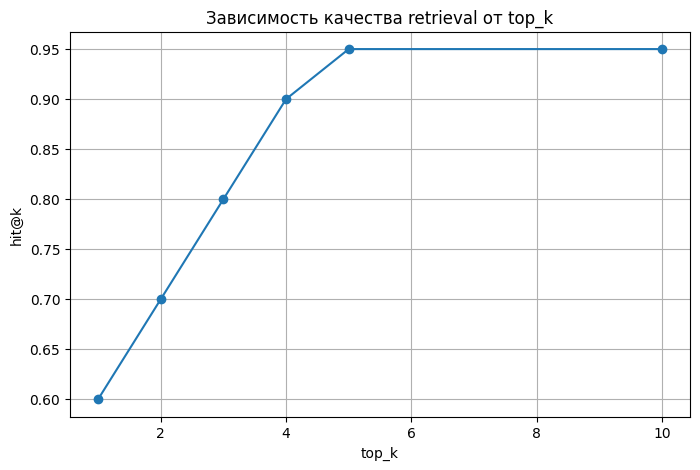

saved: artifacts/hit_at_k_plot.png


In [11]:
k_values = [1, 2, 3, 4, 5, 10]
hits = []
for k in k_values:
    hits_k = 0
    for item in qa_benchmark:
        retrieved = search(item["query"], top_k=k)
        if item["relevant_doc_ids"] in retrieved["doc_id"].tolist():
            hits_k += 1
    hits.append(hits_k / len(qa_benchmark))

plt.figure(figsize=(8,5))
plt.plot(k_values, hits, marker='o')
plt.xlabel("top_k")
plt.ylabel("hit@k")
plt.title("Зависимость качества retrieval от top_k")
plt.grid(True)
plt.savefig("artifacts/hit_at_k_plot.png")
plt.show()
print("saved: artifacts/hit_at_k_plot.png")